In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import find_peaks

In [6]:
import os

print(os.path.exists("data/processed/mie_materials_v1.npz"))

False


In [8]:
data = np.load("../data/processed/mie_materials_v1.npz", allow_pickle=False)

wl = data["wavelengths_nm"]
materials = data["material_id"]
radii = data["radius_nm"]
sigma_sca = data["sigma_sca"]

print(wl.shape, materials.shape, radii.shape, sigma_sca.shape)

(61,) (700,) (700,) (700, 61)


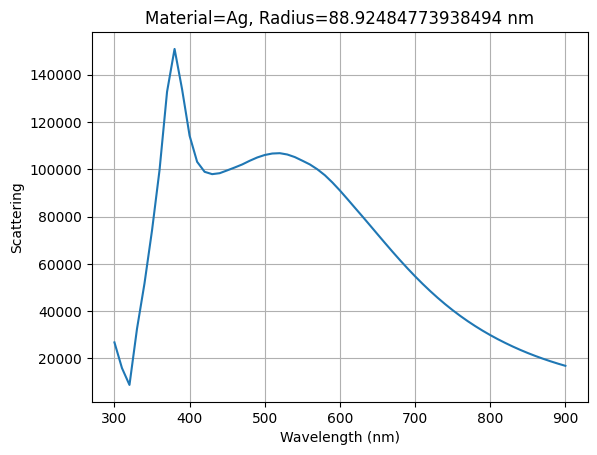

In [63]:
i = 2

plt.plot(wl, sigma_sca[i])
plt.xlabel("Wavelength (nm)")
plt.ylabel("Scattering")
plt.title(f"Material={materials[i]}, Radius={radii[i]} nm")
plt.grid(True)
plt.show()

In [64]:
peaks, _ = find_peaks(
    sigma_sca[i],
    prominence=0.14 * sigma_sca[i].max()
)
global_peak = np.argmax(sigma_sca[i])
all_peaks = np.unique(np.append(peaks, global_peak))
print(wl[all_peaks])

[380.]


In [66]:
rows = []

for i in range(len(radii)):

    y = sigma_sca[i]
    peaks, props = find_peaks(
        y,
        prominence=0.14 * y.max()
    )
    global_peak = np.argmax(y)
    all_peaks = np.unique(np.append(peaks, global_peak))

    for p in all_peaks:

        rows.append({
            "idx": i,
            "material": str(materials[i]),
            "radius_nm": float(radii[i]),
            "lambda_peak_nm": float(wl[p]),
            "sigma_peak_nm2": float(y[p]),
            "is_global_peak": bool(p == global_peak)
        })

peak_df = pd.DataFrame(rows)


print(len(peak_df))
peak_df.head()

979


,idx,material,radius_nm,lambda_peak_nm,sigma_peak_nm2,is_global_peak
0,0,Ag,655.113603,430.0,4.235705e+06,True
1,1,Ag,306.297378,390.0,1.104732e+06,True
2,2,Ag,88.924848,380.0,1.509199e+05,True
3,3,Ag,65.701254,430.0,7.933738e+04,True
4,4,Ag,822.606727,450.0,6.359938e+06,True


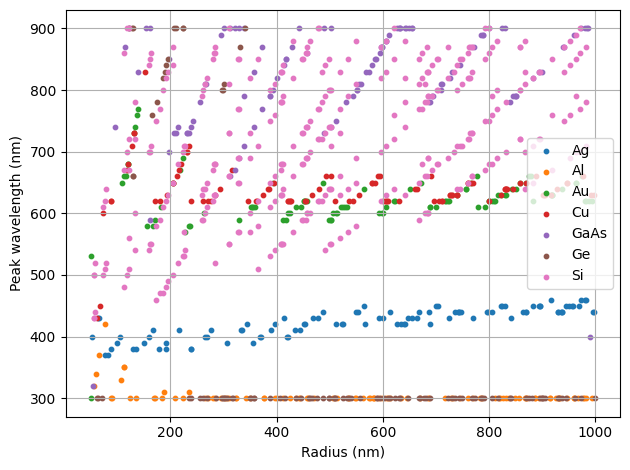

In [67]:
for mat in peak_df["material"].unique():
    sub = peak_df[peak_df["material"] == mat]
    plt.scatter(sub["radius_nm"], sub["lambda_peak_nm"], s=10, label=mat)
 
plt.xlabel("Radius (nm)")
plt.ylabel("Peak wavelength (nm)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

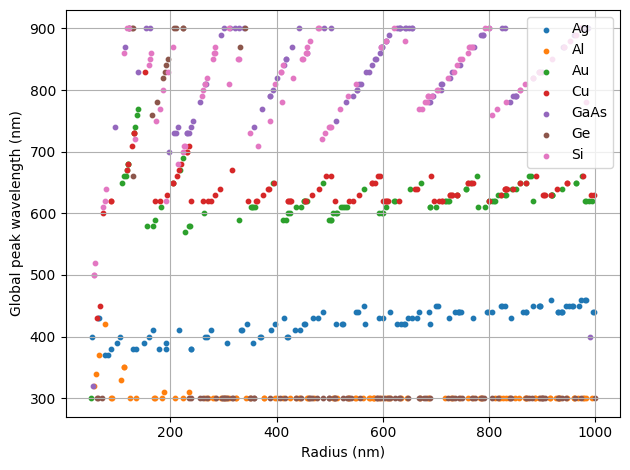

In [68]:
global_df = peak_df[peak_df["is_global_peak"] == True]

for mat in global_df["material"].unique():
    sub = global_df[global_df["material"] == mat]
    plt.scatter(sub["radius_nm"], sub["lambda_peak_nm"], s=10, label=mat)

plt.xlabel("Radius (nm)")
plt.ylabel("Global peak wavelength (nm)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [76]:
lambda_target = 850
sigma_target = 771369

In [77]:
sigma_scale = peak_df["sigma_peak_nm2"].max()

def error(row):
    e_lambda = abs(row["lambda_peak_nm"] - lambda_target) / 600
    e_sigma = abs(row["sigma_peak_nm2"] - sigma_target) / sigma_scale
    return e_lambda + e_sigma

peak_df["error"] = peak_df.apply(error, axis=1)

peak_df.sort_values("error").head(10)

,idx,material,radius_nm,lambda_peak_nm,sigma_peak_nm2,is_global_peak,error
757,640,Si,161.251088,850.0,5.517193e+05,True,0.024403
500,490,GaAs,373.307665,870.0,7.713699e+05,False,0.033333
656,612,Si,163.016904,860.0,5.833917e+05,True,0.037551
406,404,GaAs,356.774763,830.0,7.043988e+05,False,0.040774
496,487,GaAs,417.930169,850.0,1.176362e+06,True,0.044995
463,457,GaAs,418.290501,850.0,1.178481e+06,True,0.045230
636,606,Si,159.515005,840.0,5.128040e+05,True,0.045393
865,668,Si,329.645570,850.0,1.196560e+06,True,0.047239
824,658,Si,328.115324,850.0,1.202507e+06,True,0.047900
705,625,Si,205.745521,870.0,6.280451e+05,True,0.049257


In [78]:
material_summary = peak_df.groupby("material").agg(
    lambda_min=("lambda_peak_nm", "min"),
    lambda_max=("lambda_peak_nm", "max"),
    lambda_mean=("lambda_peak_nm", "mean"),
    sigma_min=("sigma_peak_nm2", "min"),
    sigma_max=("sigma_peak_nm2", "max"),
    count=("material", "count")
)

material_summary

,lambda_min,lambda_max,lambda_mean,sigma_min,sigma_max,count
material,,,,,,
Ag,370.0,460.0,424.300000,65194.399642,9.000873e+06,100
Al,300.0,420.0,304.000000,35817.957228,7.560189e+06,100
Au,300.0,770.0,623.960396,11211.567095,8.394290e+06,101
Cu,430.0,830.0,638.400000,22945.178769,8.232603e+06,100
GaAs,320.0,900.0,819.279279,16356.200493,4.930085e+06,111
Ge,300.0,900.0,402.692308,23701.684450,5.386554e+06,104
Si,430.0,900.0,717.107438,28292.386056,8.660859e+06,363


In [83]:
lambda_target = 310

In [85]:
margin = 20  # nm

candidate_materials = material_summary[
    (material_summary["lambda_min"] <= lambda_target + margin) &
    (material_summary["lambda_max"] >= lambda_target - margin)
].index.tolist()

candidate_materials

['Al', 'Au', 'GaAs', 'Ge']